In [16]:
import scanpy as sc
from scipy import stats

In [4]:
adata = sc.read_h5ad('./data/scrna.h5ad')
adata_m = sc.read_h5ad('./data/scrna_xenograft.h5ad')

In [5]:
sc.tl.rank_genes_groups(adata, 'celltype_new', method='wilcoxon')
df = sc.get.rank_genes_groups_df(adata, adata.obs['celltype_new'].unique())

In [6]:
adata_m_cd4 = adata_m[adata_m.obs['T_clusters'].str.startswith('CD4')].copy()
adata_m_cd8 = adata_m[adata_m.obs['T_clusters'].str.startswith('CD8')].copy()

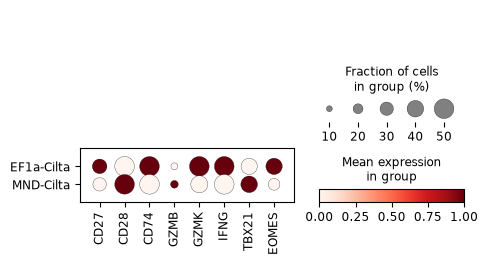

In [25]:
sc.pl.dotplot(adata_m_cd4, ['CD27', 'CD28', 'CD74', 'GZMB', 'GZMK', 'IFNG', 'TBX21', 'EOMES'], groupby='construct',
              standard_scale='var', dot_max=0.5)

In [8]:
cd4_clusters = adata[adata.obs['celltype_new'].str.startswith('CD4')].obs['celltype_new'].unique()
cd8_clusters = adata[adata.obs['celltype_new'].str.startswith('CD8')].obs['celltype_new'].unique()

for c in cd4_clusters:
    genes = df[(df['group']==c) & (df['logfoldchanges'] > 0.5) & (df['pvals_adj'] < 1e-10)]['names'].values[:50]
    print(c, genes.shape)
    sc.tl.score_genes(adata_m_cd4, genes, score_name='score_'+c)


for c in cd8_clusters:
    genes = df[(df['group']==c) & (df['logfoldchanges'] > 0.5) & (df['pvals_adj'] < 1e-10)]['names'].values[:50]
    print(c, genes.shape)
    sc.tl.score_genes(adata_m_cd8, genes, score_name='score_'+c)

CD4_1 IEG (50,)
CD4_0 Early Mem (50,)
CD4_3 Mem (50,)
CD4_4 GZMK+ (50,)
CD4_2 Early Treg (50,)
CD8_4 Late GZMB+ (50,)
CD8_3 GZMB+ (50,)
CD8_2 GZMK+ (50,)
CD8_0 Early Prolif (50,)
CD8_1 Early Eff (50,)


/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/scanpy/plotting/_anndata.py:997: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


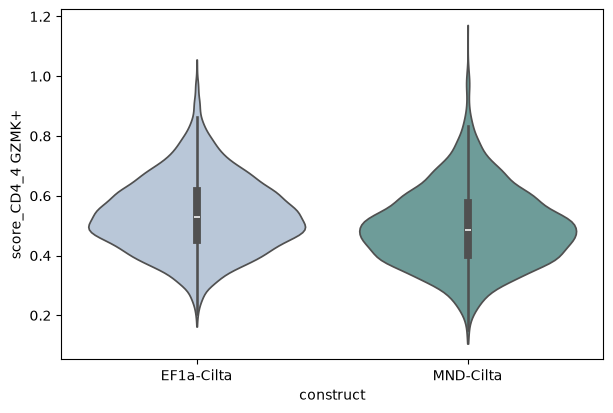

p-value: 2.447957835625343e-83


In [17]:
sc.pl.violin(adata_m_cd4, 'score_CD4_4 GZMK+', groupby='construct', palette=['#B4C6DD', '#66A4A0'],
            stripplot=False, inner='box')
_, pv = stats.mannwhitneyu(adata_m_cd4[adata_m_cd4.obs['construct']=='EF1a-Cilta'].obs['score_CD4_4 GZMK+'].values,
                           adata_m_cd4[adata_m_cd4.obs['construct']=='MND-Cilta'].obs['score_CD4_4 GZMK+'].values)
print('p-value:', pv)